<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/05_Titanic_Logistic_Regression_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TITANIC SURVIVAL - LOGISTIC REGRESSION PIPELINE

1. DATASET LOADED
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



2. TARGET DISTRIBUTION
Survived
0    549
1    342
Name: count, dtype: int64

3. TRAINING SAMPLES: 712
TESTING SAMPLES: 179

4. MODEL TRAINED SUCCESSFULLY

5. MODEL EVALUATION
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1 Score:  0.7244
ROC-AUC:   0.8437

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



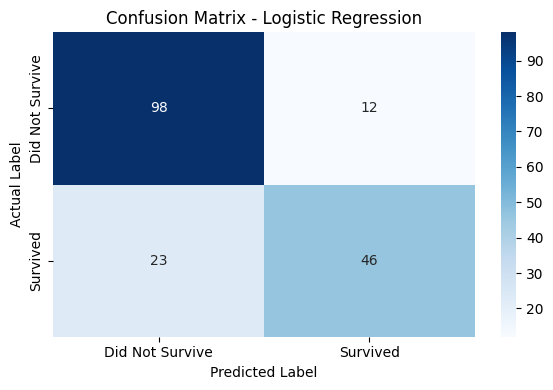

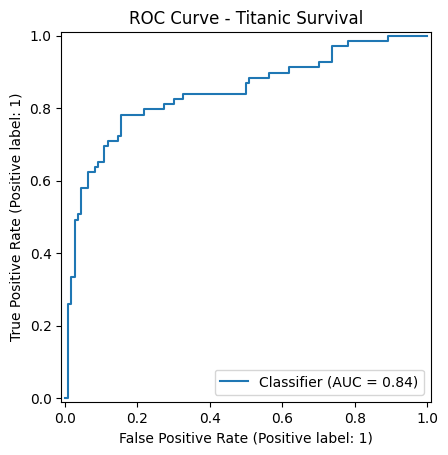


6. SAMPLE PREDICTIONS


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual Survival,Predicted Survival,Survival Probability
565,3,male,24.0,2,0,24.1500,S,0,0,0.067973
160,3,male,44.0,0,1,16.1000,S,0,0,0.047641
553,3,male,22.0,0,0,7.2250,C,1,0,0.155243
860,3,male,41.0,2,0,14.1083,S,0,0,0.035711
241,3,female,NaN,1,0,15.5000,Q,1,1,0.672378



7. CONCLUSION
A complete logistic regression pipeline was developed.
Missing values were handled, numerical features scaled,
and categorical features encoded within the pipeline.
The model was evaluated using multiple classification metrics.
Metrics saved to titanic_logistic_regression_metrics.csv


In [1]:

# PROGRAM 5: TITANIC SURVIVAL - FULL LOGISTIC REGRESSION PIPELINE

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    RocCurveDisplay
)

print("=" * 65)
print("TITANIC SURVIVAL - LOGISTIC REGRESSION PIPELINE")
print("=" * 65)

# 2. Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("\n1. DATASET LOADED")
print("Dataset shape:", df.shape)
display(df.head())

# 3. Select Features and Target
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features].copy()
y = df["Survived"].copy()

print("\n2. TARGET DISTRIBUTION")
print(y.value_counts())

# 4. Identify Column Types
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

# 5. Build Preprocessing Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# 6. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n3. TRAINING SAMPLES:", len(X_train))
print("TESTING SAMPLES:", len(X_test))

# 7. Create and Train Complete Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
print("\n4. MODEL TRAINED SUCCESSFULLY")

# 8. Make Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 9. Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n5. MODEL EVALUATION")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, zero_division=0))

# 10. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# 11. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Titanic Survival")
plt.show()

# 12. Example Predictions
sample = X_test.head(5)
sample_results = sample.copy()
sample_results["Actual Survival"] = y_test.loc[sample.index]
sample_results["Predicted Survival"] = model.predict(sample)
sample_results["Survival Probability"] = model.predict_proba(sample)[:, 1]

print("\n6. SAMPLE PREDICTIONS")
display(sample_results)

# 13. Save Evaluation Results
metrics = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}])

metrics.to_csv("titanic_logistic_regression_metrics.csv", index=False)

print("\n7. CONCLUSION")
print("A complete logistic regression pipeline was developed.")
print("Missing values were handled, numerical features scaled,")
print("and categorical features encoded within the pipeline.")
print("The model was evaluated using multiple classification metrics.")
print("Metrics saved to titanic_logistic_regression_metrics.csv")